In [1]:
import pickle as pkl
import pk_plot_library as pplib
import numpy as np
import matplotlib.pyplot as plt
from figrid.data_container import DataContainer
import copy
from scipy.optimize import curve_fit
from scipy.integrate import quad
pplib.imports()
DRAFTPATH = '/Users/cosinga/overleaf/hi_cosmo_apj/figures/'

ds = pkl.load(open('/Users/cosinga/code/hcolor/fig_md_analysis/12-29_pkdatasort.pkl', 'rb'))

ds.tickArgs(direction = 'in', labelsize = 14)
ds.legendArgs(frameon = False, loc = 'upper right', fontsize = 12, slc = (-1, -1))

ds.rowLabelArgs(pos = [0.05, 0.05], fontsize = 16, ha = 'left', va = 'bottom')
ds.colLabelArgs(pos = [0.5, 0.95], fontsize = 16, ha = 'center', va = 'top')

ds.axisArgs(xscale = 'log', yscale = 'log', xlim = [0.04, 10])
ds.axisLabelArgs('both', fontsize = 16)
ds.setOrder('space', ['real', 'redshift', 'rsd'])
ds.setOrder('snapshot', [99, 67, 50])

ds.displayAs('space', ['real', 'redshift', 'rsd'], ['Real Space', 'Redshift Space', 'Redshift Space\nDistortions'])
ds.displayAs('HI_fieldname', ['hisubhalo', 'vn', 'hiptl'], ['Galaxy Centers', 'All Particles', 'Particles in Galaxies'])
ds.displayAs('snapshot', [99, 67, 50], ['z = 0.0', 'z = 0.5', 'z = 1.0'])
ds.displayAs('color', ['red', 'blue', 'resolved', 'ratio'],
            ['HI $\\times$ Red\nCross-Power', 'HI $\\times$ Blue\nCross-Power',
            'HI $\\times$ Galaxy\nCross-Power', r'Color Ratio'])
ds.displayAs('post_process', ['corr_coef', 'theory_bias', 'obs_bias'], 
             ['r', '$b_{\\mathrm{th}}$', '$b_{\\mathrm{obs}}$'])

ds.setColors('post_process', ['pink', 'lime', 'cyan'], ['corr_coef', 'theory_bias', 'obs_bias'])
ds.setColors('color', ['red', 'blue', 'gray'], ['red', 'blue', 'resolved'])
ds.setColors('space', ['green', 'orange'], ['real', 'redshift'])
ds.setColors('HI_fieldname', ['firebrick', 'saddlebrown', 'sandybrown'], ['vn', 'hiptl', 'hisubhalo'])
snapshots = ds.getAttrVals('snapshot')
snapshots.sort()
snapshots.reverse()
ds.setColors('snapshot', 'viridis', snapshots)

ds.setXLabel(pplib.wnum())

from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck15')
def kaiser(z, bias):
    D = cosmo.growthFactor(z, derivative = 0)
    dDdz = cosmo.growthFactor(z, derivative = 1)
    f = -dDdz * (z + 1) / D
    beta = f / bias
    return (1 + 2/3 * beta + 1/5 * beta**2)
def kaiserX(z, bias1, bias2, cc):
    D = cosmo.growthFactor(z, derivative = 0)
    dDdz = cosmo.growthFactor(z, derivative = 1)
    f = -dDdz * (z + 1) / D
    kaiser = (1 + 1/3 * (f / bias1 + f / bias2)/cc + 1/5 * f**2 / bias1 / bias2 / cc)
    boost = kaiser
    return boost
def Plin(k, z):
    return cosmo.matterPowerSpectrum(k, z)

In [2]:
def calc_obs_bias(ip):
    ptlip = {'is_auto':True, 'fieldname':'ptl', 'ptl_species':'ptl', 'mas':ip['mas'],
            'path':ip['path'], 'grid_resolution':ip['grid_resolution'],
            'simname':ip['simname'], 'axis':0, 'snapshot':ip['snapshot'],
            'space':ip['space']}
    ptl_auto = ds.getMatching(ptlip)
    if len(ptl_auto) > 1:
        print('found too many particles')
        for i in ptl_auto:
            print(i.attrs)
    
    ptl_auto = ptl_auto[0]
    
    auto = ds.getMatching(ip)
    biases = []
    for i in range(len(auto)):
        
        data = [auto[i].data[0], np.sqrt(auto[i].data[1] / ptl_auto.data[1])]
        dc = DataContainer(data)
        dc.update(copy.deepcopy(auto[i].attrs))
        dc.add('post_process','obs_bias')
        dc.add('is_auto', False)
        dc.add('denominator', 'ptl')
        dc.add('_post_time', 'now')

        biases.append(dc)
    return biases

def calc_th_bias(ip):
    ptlip = {'is_auto':True, 'fieldname':'ptl', 'ptl_species':'ptl', 'mas':ip['mas'],
            'path':ip['path'], 'grid_resolution':ip['grid_resolution'],
            'simname':ip['simname'], 'axis':0, 'snapshot':ip['snapshot'],
            'space':ip['space']}
    ptl_auto = ds.getMatching(ptlip)
    if len(ptl_auto) > 1:
        print('found too many particles')
        for i in ptl_auto:
            print(i.attrs)
    
    ptl_auto = ptl_auto[0]
    
    cross = ds.getMatching(ip)
    biases = []
    for i in range(len(cross)):
        
        data = [cross[i].data[0], cross[i].data[1] / ptl_auto.data[1]]
        dc = DataContainer(data)
        dc.update(copy.deepcopy(cross[i].attrs))
        dc.add('post_process','theory_bias')
        dc.add('denominator', 'ptl')
        dc.add('_post_time', 'now')
        biases.append(dc)
    return biases
def save_bias(biases):
    SAVE_ATTRS = ['simname', 'snapshot', 'space', 'post_process', 'color', 'model']
    bvals = []
    for bias in biases:
        bval = bias.getData()[1][1]
        attrs = [bias.get(attr) for attr in SAVE_ATTRS]
        bvals.append([bval, attrs])
    return bvals


In [3]:
simnames = ['tng100', 'tng300']
snapshots = [50, 67, 99]
spaces = ['real', 'redshift']
bvals = []
for name in simnames:
    for snap in snapshots:
        for space in spaces:
            
            print("\n", name, snap, space)
            hiip = {'is_auto':True, "HI_fieldname":['vn', 'hiptl'],      
              'axis':0, 'grid_resolution':800, 'simname': name,
              'mas':'CICW', 'snapshot':snap, 'space':space,
             'path':'fiducial', 'post_process':'no key found'}
            obs_biases = calc_obs_bias(hiip)
            print('hi biases:', len(obs_biases))
            ds.extend(obs_biases)
            bvals.extend(save_bias(obs_biases))
            galip = {'gal_res':'diemer',
                      'gal_species':'stmass', 'sim_resolution':'high', 
                     'axis':0, 'grid_resolution':800,
                      'censat':['no key found', 'both'], 'mas':'CICW', 
                     'color': ['blue', 'red', 'resolved'], 'fieldname':'galaxy',
                     'path':'fiducial', 'simname':name, 'space':space,
                    'snapshot':snap, 'post_process':'no key found'}
            obs_biases = calc_obs_bias(galip)
            print('galaxy biases:', len(obs_biases))
            bvals.extend(save_bias(obs_biases))
            ds.extend(obs_biases)


 tng100 50 real
hi biases: 5
galaxy biases: 3

 tng100 50 redshift
hi biases: 5
galaxy biases: 3

 tng100 67 real
hi biases: 5
galaxy biases: 3

 tng100 67 redshift
hi biases: 5
galaxy biases: 3

 tng100 99 real
hi biases: 5
galaxy biases: 3

 tng100 99 redshift
hi biases: 5
galaxy biases: 3

 tng300 50 real
hi biases: 5
galaxy biases: 3

 tng300 50 redshift
hi biases: 5
galaxy biases: 3

 tng300 67 real
hi biases: 5
galaxy biases: 3

 tng300 67 redshift
hi biases: 5
galaxy biases: 3

 tng300 99 real
hi biases: 5
galaxy biases: 3

 tng300 99 redshift
hi biases: 5
galaxy biases: 3


In [4]:
ip = {'is_auto':False, 'HI_fieldname':['vn','hiptl'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[99, 67, 50], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW',
     'color':['blue', 'red', 'resolved'], 'space':['redshift']}
ptlpk = ds.getMatching({'is_auto':True, 'fieldname':'ptl', 'ptl_species':'ptl', 'mas':ip['mas'],
            'path':'fiducial', 'grid_resolution':ip['grid_resolution'],
            'simname':ip['simname'], 'axis':0, 'snapshot':99,
            'space':'real'})
ptlk99 = ptlpk[0].getData()[0]
pklin99 = Plin(ptlk99, 0)
ptlpk99 = ptlpk[0].getData()[1]
ptlpk = ds.getMatching({'is_auto':True, 'fieldname':'ptl', 'ptl_species':'ptl', 'mas':ip['mas'],
            'path':'fiducial', 'grid_resolution':ip['grid_resolution'],
            'simname':ip['simname'], 'axis':0, 'snapshot':67,
            'space':'real'})
ptlk67 = ptlpk[0].getData()[0]
ptlpk67 = ptlpk[0].getData()[1]
pklin67 = Plin(ptlk99, ptlpk[0].get('redshift'))
ptlpk = ds.getMatching({'is_auto':True, 'fieldname':'ptl', 'ptl_species':'ptl', 'mas':ip['mas'],
            'path':'fiducial', 'grid_resolution':ip['grid_resolution'],
            'simname':ip['simname'], 'axis':0, 'snapshot':50,
            'space':'real'})
ptlk50 = ptlpk[0].getData()[0]
ptlpk50 = ptlpk[0].getData()[1]
pklin50 = Plin(ptlk99, ptlpk[0].get('redshift'))

In [5]:
bhi = [0.77, 1.02, 1.3]

sighi = [2.39, 3.06, 2.66]
ptlpks = [(ptlk99, ptlpk99), (ptlk67, ptlpk67), (ptlk50, ptlpk50)]
redshifts = [0, 0.5, 1]
snapshots = [99, 67, 50]
omegahis = [7.4e-4, 6.663e-4, 6e-4]
color_idxs = ['blue', 'red', 'resolved']
nmodes = pkl.load(open('nmodes.pkl', 'rb'))
kmin = [0.03]
kmax = [0.1, 0.3, 0.5, 1, 2, 5, 10]

def omegam(snap):
    a = 1 / (1 + redshifts[snap])
    om0 = 0.3089 # from TNG website
    oml = 0.6911 # from TNG website
    return om0 * a**-3 / (oml + om0 * a**-3)

def thi(omegahi, snap):
    h = 0.6774
    om = omegam(snap); oml = 0.6911
    return 180 * omegahi * h * (1 + redshifts[snap])**2 / (om * (1 + redshifts[snap])**3 + oml)**0.5

def omegahi(thi, snap):
    h = 0.6774
    om = omegam(snap); oml = 0.6911
    return thi / 180 / h / (1 + redshifts[snap])**2 * np.sqrt(om * (1 + redshifts[snap])**3 + oml)

def get_key(model, color, snap):
    return '%s_%s_%d'%(model, color, snap)

def key_to_vals(key):
    splt = key.split('_')
    return splt[0], splt[1], int(splt[2])

def print_ohi(_thi_dict):
    for k, v in _thi_dict.items():
        print(k)
        model, color, snap = key_to_vals(k)
        snap_idx = snapshots.index(snap)
        omegas = omegahi(np.array(v), snap_idx)
        
        print(omegas)
        print('\n')
    return

def get_uncert(kmask, pk):
    sig = np.sqrt(2 / nmodes[kmask]) * pk
    return sig

In [6]:
def A_50(k, C):
    snap = 50; snap_idx = snapshots.index(snap)
    boost = kaiser(redshifts[snap_idx], bhi[snap_idx])
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx]**2 * boost * ptlpks[snap_idx][1][kmask] * C**2
def A_67(k, C):
    snap = 67; snap_idx = snapshots.index(snap)
    boost = kaiser(redshifts[snap_idx], bhi[snap_idx])
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx]**2 * boost * ptlpks[snap_idx][1][kmask] * C**2
def A_99(k, C):
    snap = 99; snap_idx = snapshots.index(snap)
    boost = kaiser(redshifts[snap_idx], 1)
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx]**2 * boost * ptlpks[snap_idx][1][kmask] * C**2

def B_50(k, C):
    snap = 50; snap_idx = snapshots.index(snap)
    ip = {'is_auto':False, 'fieldname':'vn',
      'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
      'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
     'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}

    kdep_biashi = ds.getMatching(ip)[0].getData()[1]
    boost = kaiser(redshifts[snap_idx], bhi[snap_idx])
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return kdep_biashi[kmask]**2 * boost * ptlpks[snap_idx][1][kmask] * C**2
def B_67(k, C):
    snap = 67; snap_idx = snapshots.index(snap)
    ip = {'is_auto':False, 'fieldname':'vn',
      'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
      'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
     'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}

    kdep_biashi = ds.getMatching(ip)[0].getData()[1]
    boost = kaiser(redshifts[snap_idx], bhi[snap_idx])
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return kdep_biashi[kmask]**2 * boost * ptlpks[snap_idx][1][kmask] * C**2
def B_99(k, C):
    snap = 99; snap_idx = snapshots.index(snap)
    ip = {'is_auto':False, 'fieldname':'vn',
      'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
      'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
     'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}

    kdep_biashi = ds.getMatching(ip)[0].getData()[1]
    boost = kaiser(redshifts[snap_idx], bhi[snap_idx])
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return kdep_biashi[kmask]**2 * boost * ptlpks[snap_idx][1][kmask] * C**2

def integrand(mu, k, real_pk, f, bias, sigma):
    kaiser = real_pk * (1 + 2*f*mu**2/bias + f**2 * mu**4 / bias**2)
    fog = 1/(1 + 0.5 * k**2 * mu**2 * sigma**2)**2
    return kaiser * fog

def solve_integral(k, real_pk, z, bias, sigma):
    # Define the limits of integration
    lower_limit = -1.0
    upper_limit = 1.0
    
    D = cosmo.growthFactor(z, derivative = 0)
    dDdz = cosmo.growthFactor(z, derivative = 1)
    f = -dDdz * (z + 1) / D
    # Use quad from scipy to perform the numerical integration
    result, error = quad(integrand, lower_limit, upper_limit, args=(k, real_pk, f, bias, sigma)) 
    return result * 0.5



def C_50(k, C):
    snap = 50;
    snap_idx = snapshots.index(snap)

    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integral(kval, bhi[snap_idx]**2 * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], sighi[snap_idx])
        
    return pk * C**2
def C_67(k, C):
    snap = 67; 
    snap_idx = snapshots.index(snap)

    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integral(kval, bhi[snap_idx]**2 * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], sighi[snap_idx])
        
    return pk * C**2
def C_99(k, C):
    snap = 99;
    snap_idx = snapshots.index(snap)

    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integral(kval, bhi[snap_idx]**2 * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], sighi[snap_idx])
        
    return pk * C**2

def D_50(k, C):
    snap = 50;
    snap_idx = snapshots.index(snap)
    
    ip = {'is_auto':False, 'fieldname':'vn',
      'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
      'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
     'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}

    kdep_biashi = ds.getMatching(ip)[0].getData()[1]
    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integral(kval, kdep_biashi[i]**2 * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], sighi[snap_idx])
        
    return pk * C**2

def D_67(k, C):
    snap = 67;
    snap_idx = snapshots.index(snap)
    
    ip = {'is_auto':False, 'fieldname':'vn',
      'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
      'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
     'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}

    kdep_biashi = ds.getMatching(ip)[0].getData()[1]
    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integral(kval, kdep_biashi[i]**2 * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], sighi[snap_idx])
        
    return pk * C**2
def D_99(k, C):
    snap = 99;
    snap_idx = snapshots.index(snap)
    
    ip = {'is_auto':False, 'fieldname':'vn',
      'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
      'post_process':['obs_bias'], 'snapshot':[snap], 'space':'real',
     'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}

    kdep_biashi = ds.getMatching(ip)[0].getData()[1]
    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integral(kval, kdep_biashi[i]**2 * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], sighi[snap_idx])
        
    return pk * C**2
    

In [7]:
def plot_ohi_basic(_thi_dict, _cov_dict):
    ncols = 3
    nrows = len(_thi_dict.keys()) // 3 + 1
    fig, axes = plt.subplots(nrows, ncols, figsize = (3 * ncols + 2, 3 * nrows + 1), sharey = True)
    axes = np.ravel(axes)
    ax_idx = 0
    for k, v in _thi_dict.items():
        model, color, snap = key_to_vals(k)
        snap_idx = snapshots.index(snap)
        omegas = omegahi(np.array(v), snap_idx)
        actual = omegahis[snap_idx]
        
        
        plt.sca(axes[ax_idx])
        plt.title(k)
        ksnap = k_dict[snap]
        keff = []
        yerr = []
#         yerr = [[], []]
        for i in range(len(ksnap)):
            keff.append(np.sum(ksnap[i]) / len(ksnap[i]))
            uncert_thi = np.sqrt(np.diag(_cov_dict[k][i]))[0][0]
            yerr.append(omegahi(uncert_thi, snap_idx))
#             lower = omegahi(v[i] - uncert_thi, snap_idx)
#             upper = omegahi(v[i] + uncert_thi, snap_idx)
#             yerr[0].append(lower - omegas[i])
#             yerr[1].append(upper - omegas[i])
#         print(yerr)
        plt.errorbar(keff, omegas, yerr = yerr, fmt = 'bo')
        plt.plot(keff, [actual]*len(keff), color = 'black')
        plt.xscale('log')
        ax_idx += 1
    plt.ylim(0, 0.0008)
    return fig, axes
def print_ohi(_thi_dict):
    for k, v in _thi_dict.items():
        print(k)
        model, color, snap = key_to_vals(k)
        snap_idx = snapshots.index(snap)
        omegas = omegahi(np.array(v), snap_idx)
        
        print(omegas)
        print('\n')
    return

In [8]:

thi_dict = {}
k_dict = {}
cov_dict = {}

A_HI_50
[0.00053743 0.00051156 0.0004719  0.00036411 0.00028537 0.00026758
 0.00031194]


B_HI_50
[0.00058001 0.00054436 0.00050571 0.00039262 0.0002944  0.00020303
 0.00015556]


C_HI_50
[0.00057443 0.00058679 0.00059685 0.0006168  0.00067742 0.0009189
 0.00127437]


D_HI_50
[0.00058387 0.00058864 0.00060205 0.00062606 0.00067018 0.00075142
 0.00081838]




(<Figure size 792x504 with 6 Axes>,
 array([<AxesSubplot:title={'center':'A_HI_50'}>,
        <AxesSubplot:title={'center':'B_HI_50'}>,
        <AxesSubplot:title={'center':'C_HI_50'}>,
        <AxesSubplot:title={'center':'D_HI_50'}>, <AxesSubplot:>,
        <AxesSubplot:>], dtype=object))

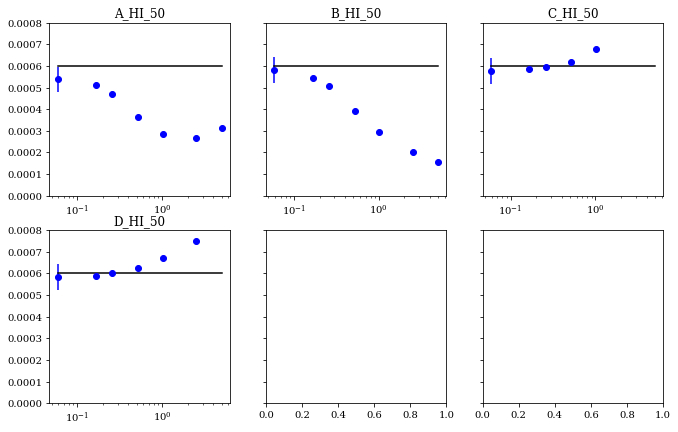

In [9]:
snap = 50; snap_idx = snapshots.index(snap)
ip = {'is_auto':True, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap],
      'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW',
     'space':['redshift']}
hiauto = ds.getMatching(ip)[0].getData()
k_dict[snap] = []
model_func = [A_50, B_50, C_50, D_50]
for min_idx in range(len(kmin)):
    for max_idx in range(len(kmax)):
        if (kmax[max_idx] > kmin[min_idx]):
            kmask = (ptlpks[snap_idx][0] >= kmin[min_idx]) & (ptlpks[snap_idx][0] < kmax[max_idx])
            thi_snap = thi(omegahis[snap_idx], snap_idx)
            xdata = ptlpks[snap_idx][0][kmask]
            k_dict[snap].append(xdata)
            for i, model in enumerate('ABCD'):


                key = get_key(model, 'HI', snap)
                if key not in thi_dict:
                    thi_dict[key] = []
                if key not in cov_dict:
                    cov_dict[key] = []
                
                ydata = hiauto[1][kmask]
                uncert = get_uncert(kmask, ydata * thi_snap**2)

                val, cov = curve_fit(model_func[i], xdata, ydata * thi_snap**2, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
                thi_dict[key].append(val[0])
                cov_dict[key].append(cov[0])
print_ohi(thi_dict)
plot_ohi_basic(thi_dict, cov_dict)

A_HI_50
[0.00053743 0.00051156 0.0004719  0.00036411 0.00028537 0.00026758
 0.00031194]


B_HI_50
[0.00058001 0.00054436 0.00050571 0.00039262 0.0002944  0.00020303
 0.00015556]


C_HI_50
[0.00057443 0.00058679 0.00059685 0.0006168  0.00067742 0.0009189
 0.00127437]


D_HI_50
[0.00058387 0.00058864 0.00060205 0.00062606 0.00067018 0.00075142
 0.00081838]


A_HI_67
[0.00061529 0.00055581 0.00049006 0.00036158 0.0002875  0.0002907
 0.00035275]


B_HI_67
[0.00063919 0.00059058 0.00054434 0.00043366 0.00033513 0.00023388
 0.00017908]


C_HI_67
[0.00062329 0.00062053 0.00061904 0.00063341 0.00070175 0.00098943
 0.00138491]


D_HI_67
[0.00064501 0.00065433 0.0006775  0.00073966 0.0008249  0.00094487
 0.0010325 ]




(<Figure size 792x720 with 9 Axes>,
 array([<AxesSubplot:title={'center':'A_HI_50'}>,
        <AxesSubplot:title={'center':'B_HI_50'}>,
        <AxesSubplot:title={'center':'C_HI_50'}>,
        <AxesSubplot:title={'center':'D_HI_50'}>,
        <AxesSubplot:title={'center':'A_HI_67'}>,
        <AxesSubplot:title={'center':'B_HI_67'}>,
        <AxesSubplot:title={'center':'C_HI_67'}>,
        <AxesSubplot:title={'center':'D_HI_67'}>, <AxesSubplot:>],
       dtype=object))

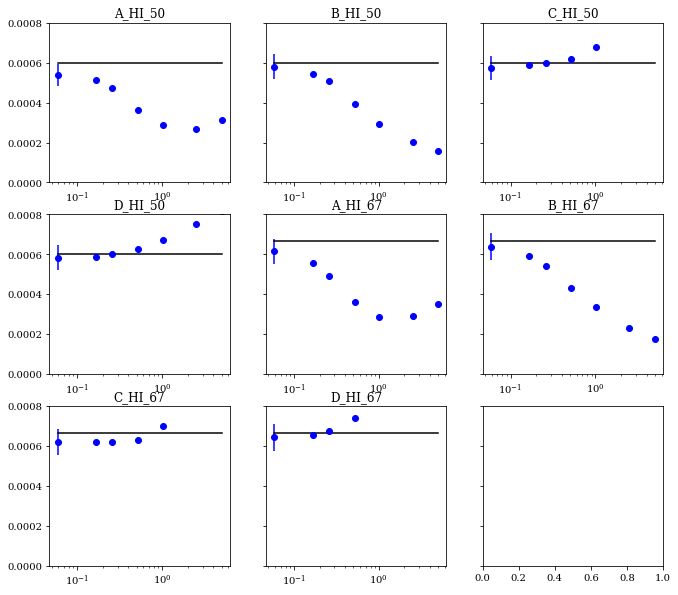

In [10]:
snap = 67; snap_idx = snapshots.index(snap)
ip = {'is_auto':True, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap],
      'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW',
     'space':['redshift']}
hiauto = ds.getMatching(ip)[0].getData()
k_dict[snap] = []
model_func = [A_67, B_67, C_67, D_67]
for min_idx in range(len(kmin)):
    for max_idx in range(len(kmax)):
        if (kmax[max_idx] > kmin[min_idx]):
            kmask = (ptlpks[snap_idx][0] >= kmin[min_idx]) & (ptlpks[snap_idx][0] < kmax[max_idx])
            thi_snap = thi(omegahis[snap_idx], snap_idx)
            xdata = ptlpks[snap_idx][0][kmask]
            k_dict[snap].append(xdata)
            for i, model in enumerate('ABCD'):


                key = get_key(model, 'HI', snap)
                if key not in thi_dict:
                    thi_dict[key] = []
                if key not in cov_dict:
                    cov_dict[key] = []
                
                ydata = hiauto[1][kmask]
                uncert = get_uncert(kmask, ydata * thi_snap**2)

                val, cov = curve_fit(model_func[i], xdata, ydata * thi_snap**2, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
                thi_dict[key].append(val[0])
                cov_dict[key].append(cov[0])
print_ohi(thi_dict)
plot_ohi_basic(thi_dict, cov_dict)

A_HI_50
[0.00053743 0.00051156 0.0004719  0.00036411 0.00028537 0.00026758
 0.00031194]


B_HI_50
[0.00058001 0.00054436 0.00050571 0.00039262 0.0002944  0.00020303
 0.00015556]


C_HI_50
[0.00057443 0.00058679 0.00059685 0.0006168  0.00067742 0.0009189
 0.00127437]


D_HI_50
[0.00058387 0.00058864 0.00060205 0.00062606 0.00067018 0.00075142
 0.00081838]


A_HI_67
[0.00061529 0.00055581 0.00049006 0.00036158 0.0002875  0.0002907
 0.00035275]


B_HI_67
[0.00063919 0.00059058 0.00054434 0.00043366 0.00033513 0.00023388
 0.00017908]


C_HI_67
[0.00062329 0.00062053 0.00061904 0.00063341 0.00070175 0.00098943
 0.00138491]


D_HI_67
[0.00064501 0.00065433 0.0006775  0.00073966 0.0008249  0.00094487
 0.0010325 ]


A_HI_99
[0.00076682 0.0006225  0.00051483 0.00036535 0.00029417 0.00030887
 0.00038009]


B_HI_99
[0.00076319 0.00066366 0.00059619 0.00047276 0.00037013 0.00025963
 0.00019493]


C_HI_99
[0.00073453 0.00063861 0.00057967 0.00053714 0.00058765 0.00084032
 0.00117809]


D_HI_99
[0.0

(<Figure size 792x1152 with 15 Axes>,
 array([<AxesSubplot:title={'center':'A_HI_50'}>,
        <AxesSubplot:title={'center':'B_HI_50'}>,
        <AxesSubplot:title={'center':'C_HI_50'}>,
        <AxesSubplot:title={'center':'D_HI_50'}>,
        <AxesSubplot:title={'center':'A_HI_67'}>,
        <AxesSubplot:title={'center':'B_HI_67'}>,
        <AxesSubplot:title={'center':'C_HI_67'}>,
        <AxesSubplot:title={'center':'D_HI_67'}>,
        <AxesSubplot:title={'center':'A_HI_99'}>,
        <AxesSubplot:title={'center':'B_HI_99'}>,
        <AxesSubplot:title={'center':'C_HI_99'}>,
        <AxesSubplot:title={'center':'D_HI_99'}>, <AxesSubplot:>,
        <AxesSubplot:>, <AxesSubplot:>], dtype=object))

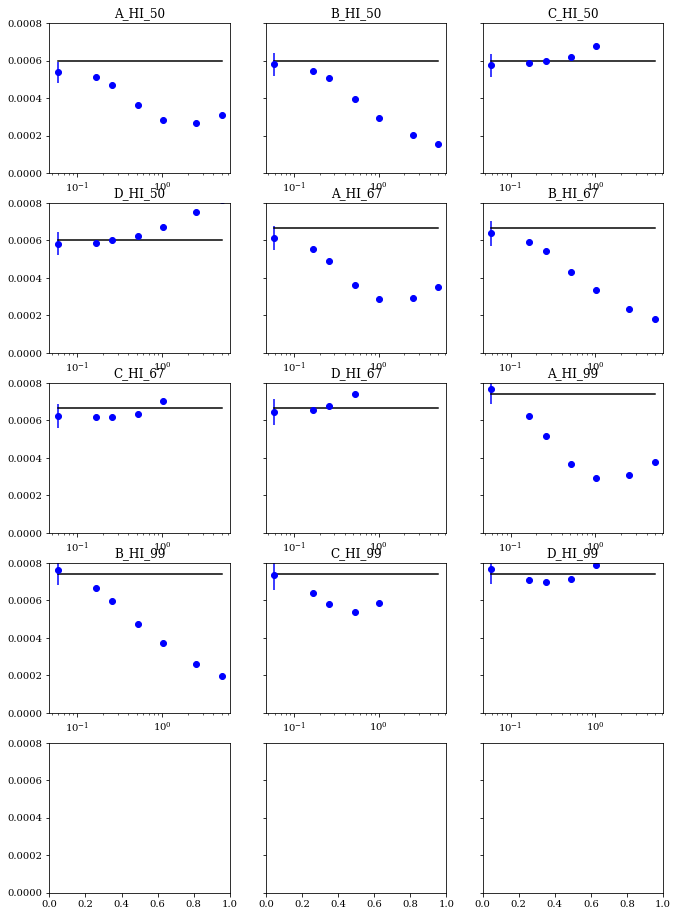

In [11]:
snap = 99; snap_idx = snapshots.index(snap)
ip = {'is_auto':True, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap],
      'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW',
     'space':['redshift']}
hiauto = ds.getMatching(ip)[0].getData()
k_dict[snap] = []
model_func = [A_99, B_99, C_99, D_99]
for min_idx in range(len(kmin)):
    for max_idx in range(len(kmax)):
        if (kmax[max_idx] > kmin[min_idx]):
            kmask = (ptlpks[snap_idx][0] >= kmin[min_idx]) & (ptlpks[snap_idx][0] < kmax[max_idx])
            thi_snap = thi(omegahis[snap_idx], snap_idx)
            xdata = ptlpks[snap_idx][0][kmask]
            k_dict[snap].append(xdata)
            for i, model in enumerate('ABCD'):


                key = get_key(model, 'HI', snap)
                if key not in thi_dict:
                    thi_dict[key] = []
                if key not in cov_dict:
                    cov_dict[key] = []
                
                ydata = hiauto[1][kmask]
                uncert = get_uncert(kmask, ydata * thi_snap**2)

                val, cov = curve_fit(model_func[i], xdata, ydata * thi_snap**2, p0 = (thi_snap), sigma = uncert, absolute_sigma = True)
                thi_dict[key].append(val[0])
                cov_dict[key].append(cov[0])
print_ohi(thi_dict)
plot_ohi_basic(thi_dict, cov_dict)

In [12]:
pkl.dump(thi_dict, open('thi_fits_auto.pkl', 'wb'))
pkl.dump(k_dict, open('k_fits_auto.pkl', 'wb'))
pkl.dump(cov_dict, open('cov_fits_auto.pkl', 'wb'))